# QPA Fidelity Decay — End-to-End Dynamic Circuit Notebook

This notebook walks through the full QPA (Quantum Purification Algorithm) experiment pipeline using **dynamic circuits** (HybridStrategy with `if_test` branching):

1. **Configuration** — Define experiment parameters
2. **Backend Setup** — Connect to IBM Quantum hardware (`ibm_marrakesh`)
3. **Circuit Generation** — Build dynamic circuits with `HybridStrategy` (N=3) and `HybridStrategy_n5_ntrials_1` (N=5, flat if)
4. **Transpilation** — N=3: unrolled-layout strategy; N=5: static-layout strategy (extract layout from the if branch)
5. **Noise Application** — Apply Pauli Twirling noise for each λ point
6. **Submission** — Send circuits to IBM and collect results
7. **Result Processing** — Extract counts and compute fidelity
8. **Plotting** — Compare experimental fidelity decay against theory

**Experiments:**
- N=3, K=2, T=1 (3 registers, 2 qubits each, 1 trial round)
- N=5, K=2, T=1 (5 registers, 2 qubits each, 1 trial round — flat if strategy)

**Key difference from the static (unrolled) notebook:** The dynamic circuit uses mid-circuit measurement and classical branching (`if_test`) to handle all execution paths in a single circuit, rather than generating separate static circuits for each path.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Add dynamic_experiment to path so we can import HybridStrategy and utils
sys.path.insert(0, os.path.join(os.getcwd(), "dynamic_experiment"))

from qpa_engine import HybridStrategy, HybridStrategy_n5_ntrials_1
from utils import (
    transpile_dynamic_best_of_n_unrolled,
    transpile_dynamic_best_of_n,
    get_static_depth,
)

from core.noise_models import PauliTwirlingStrategy
from execution.backend_handler import IBMRuntimeHandler
from analysis.result_processor import ResultProcessor
from analysis.fidelity_calc import calculate_success_rate

from qiskit.circuit import CircuitInstruction
from qiskit.circuit.library import XGate, RZGate
from qiskit_ibm_runtime import SamplerV2 as IBMSampler

print("Imports loaded.")

Imports loaded.


## Step 1: Configuration

Define the experiment parameters for both runs. We use the **dynamic** circuit strategy (HybridStrategy) with **Pauli Twirling** noise on the real `ibm_marrakesh` backend.

| Parameter | Description | Value |
|-----------|-------------|-------|
| `N` | Number of registers (must be odd) | 3, 5 |
| `K` | Qubits per register (qudit dimension d=2^k) | 2 |
| `T` (n_trials) | Number of QPA trial rounds (circuit depth) | 1 |
| `POINTS` | Number of λ (noise) values to sweep | 25 |
| `LAMBDA_MIN/MAX` | Noise parameter range | 0.0 – 1.0 |
| `N_RANDOM` | Pauli twirling instances per λ point (ensemble size) | 50 |
| `SHOTS` | Total shots budget per λ point (split across instances) | 10000 |
| `BATCH_SIZE` | Circuits per IBM job submission | 50 |
| `N_SEEDS` | Number of transpiler seeds to try (best-of-N) | 20 |
| `DEVICE` | IBM Quantum backend | ibm_marrakesh |

In [2]:
# ----- Experiment Parameters -----
K = 2                # Qubits per register (d = 2^K = 4)
T = 1                # Number of QPA trial rounds
POINTS = 25          # Number of lambda values in the sweep
LAMBDA_MIN = 0.0     # Minimum noise parameter
LAMBDA_MAX = 1.0     # Maximum noise parameter
N_RANDOM = 50        # Pauli twirling instances per circuit (ensemble size)
SHOTS = 10000        # Total shots budget per lambda point
BATCH_SIZE = 50      # Max circuits per job submission
N_SEEDS = 20         # Number of transpiler seeds to try (best-of-N)
DEVICE = "ibm_marrakesh"  # IBM Quantum backend

# The two experiments
EXPERIMENTS = [
    {"n": 3, "k": K, "t": T, "label": "N=3, K=2, T=1"},
    {"n": 5, "k": K, "t": T, "label": "N=5, K=2, T=1"},
]

# Derived
lambdas = np.linspace(LAMBDA_MIN, LAMBDA_MAX, POINTS)
shots_per_circuit = max(1, SHOTS // N_RANDOM)

print(f"Lambda sweep: {POINTS} points from {LAMBDA_MIN} to {LAMBDA_MAX}")
print(f"Shots per circuit instance: {shots_per_circuit}")
print(f"Pauli twirling instances per lambda: {N_RANDOM}")
print(f"Transpiler seeds to try: {N_SEEDS}")
print(f"Experiments: {[e['label'] for e in EXPERIMENTS]}")

Lambda sweep: 25 points from 0.0 to 1.0
Shots per circuit instance: 200
Pauli twirling instances per lambda: 50
Transpiler seeds to try: 20
Experiments: ['N=3, K=2, T=1', 'N=5, K=2, T=1']


## Step 2: Backend Setup

Connect to the real IBM Quantum backend `ibm_marrakesh` via `QiskitRuntimeService`. Authentication is loaded from the `.env` file (`IBM_QUANTUM_TOKEN` or `CRN`).

In [3]:
# Initialize the IBM Runtime backend handler
backend_handler = IBMRuntimeHandler(backend_name=DEVICE)
backend = backend_handler.get_backend()

print(f"Backend: {backend.name}")
print(f"Number of qubits: {backend.num_qubits}")
print(f"Backend status: {backend.status()}")

qiskit_runtime_service._discover_account:WARNING:2026-03-12 21:13:06,009: Loading account with the given token. A saved account will not be used.


Connecting to IBM Runtime Service via channel='ibm_cloud'...
Backend: ibm_marrakesh
Number of qubits: 156
Backend status: <qiskit_ibm_runtime.models.backend_status.BackendStatus object at 0x11a188830>


## Step 3: Circuit Generation (Dynamic Circuits)

For **N=3**, we use the standard **HybridStrategy** which builds a single dynamic circuit with nested `if_test` branching. With T=1, there is only one level of nesting.

For **N=5**, we use **HybridStrategy_n5_ntrials_1** which builds a flat (non-nested) `if_test` on the 2-bit classical register value. This avoids unnecessary nesting and produces a simpler circuit for transpilation.

We build **golden circuits** (no noise) to inspect and transpile.

In [4]:
# Build golden (noiseless) dynamic circuits for each experiment
golden_per_exp = {}

for exp in EXPERIMENTS:
    n = exp["n"]
    label = exp["label"]
    
    if n == 5:
        # Use flat-if strategy for N=5
        strategy = HybridStrategy_n5_ntrials_1(k=K)
    else:
        strategy = HybridStrategy(k=K, n_trials=T, n_registers=n)
    
    qc_dynamic = strategy.build_circuit(epsilon=0.0)
    
    golden_per_exp[n] = {
        'circuit': qc_dynamic,
        'strategy': strategy,
    }
    
    print(f"\n--- {label} ---")
    print(f"  Strategy: {type(strategy).__name__}")
    print(f"  Qubits: {qc_dynamic.num_qubits}")
    print(f"  Classical bits: {qc_dynamic.num_clbits}")
    print(f"  Depth: {qc_dynamic.depth()}")
    print(f"  Gate counts: {dict(qc_dynamic.count_ops())}")


--- N=3, K=2, T=1 ---
  Strategy: HybridStrategy
  Qubits: 8
  Classical bits: 4
  Depth: 7
  Gate counts: {'measure': 3, 'h': 2, 'cswap': 2, 'if_else': 2, 'reset': 1}

--- N=5, K=2, T=1 ---
  Strategy: HybridStrategy_n5_ntrials_1
  Qubits: 13
  Classical bits: 5
  Depth: 9
  Gate counts: {'h': 4, 'cswap': 4, 'measure': 4, 'if_else': 3, 'reset': 2}


### Visualize a sample circuit

Draw the dynamic circuit for N=3 to see the `if_test` branching structure.

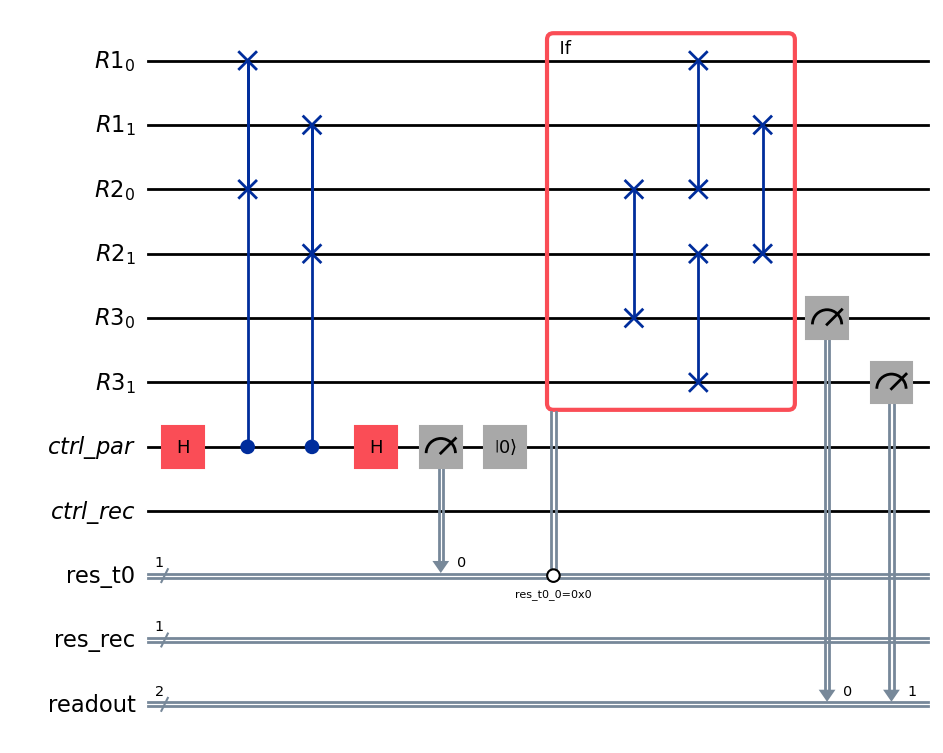

In [5]:
# Draw the golden dynamic circuit for N=3
sample_qc = golden_per_exp[3]['circuit']
sample_qc.draw('mpl', fold=120)

## Step 4: Transpilation

Qiskit's default transpiler does not produce good results for dynamic circuits. We use two different strategies depending on the circuit:

**N=3 — Unrolled-layout strategy:**
1. Build the longest unrolled path (all-success static circuit) with registers matching the dynamic circuit
2. Transpile that static circuit to extract a good initial layout
3. Re-transpile the dynamic circuit using that layout as a seed

**N=5 — Static-layout strategy (from `transpile_qpa_flat_if_5`):**
1. Extract the static **if** branch from the dynamic circuit (the longest path)
2. Transpile that static proxy to extract a good initial layout
3. Re-transpile the dynamic circuit using that layout as a seed

We try multiple transpiler seeds and pick the one with the lowest circuit depth (**best-of-N**).

In [6]:
# Transpile dynamic circuits using the appropriate strategy per experiment

def filter_2q(inst):
    """Filter for 2-qubit gates only (used for depth evaluation)."""
    return inst.operation.num_qubits == 2

transpiled_per_exp = {}

for exp in EXPERIMENTS:
    n = exp["n"]
    label = exp["label"]
    qc_dynamic = golden_per_exp[n]['circuit']
    # decompose the circuit into 2-qubit gates as without it, QiskitError: 'Target has no gates available on qubits to synthesize over.'
    qc_dynamic = qc_dynamic.decompose(reps=2)
    
    print(f"\nTranspiling dynamic circuit for {label} (best-of-{N_SEEDS} seeds)...")
    
    if n == 5:
        # N=5: static-layout strategy using the if branch
        BRANCH = 'if'
        REPS = 1
        result = transpile_dynamic_best_of_n(
            qc_dynamic, backend,
            branch=BRANCH,
            optimization_level=3,
            n_trials=N_SEEDS,
            depth_branch=BRANCH,
            filter_fn=filter_2q,
        )
    else:
        # N=3: unrolled-layout strategy
        result = transpile_dynamic_best_of_n_unrolled(
            qc_dynamic, backend,
            k=K, n_trials_qpa=T, n_registers=n,
            optimization_level=3,
            n_trials=N_SEEDS,
            depth_branch='if',
            filter_fn=filter_2q,
        )
    
    transpiled_per_exp[n] = result['circuit']
    
    print(f"  Best seed: {result['seed']}")
    print(f"  Best 2Q depth: {result['best_depth']}")
    print(f"  Avg 2Q depth: {result['avg_depth']:.1f}")
    print(f"  All depths: {result['all_depths']}")
    
    qc_tr = result['circuit']
    print(f"  Transpiled circuit: depth={qc_tr.depth()}, gates={dict(qc_tr.count_ops())}")

print("\nAll dynamic circuits transpiled.")


Transpiling dynamic circuit for N=3, K=2, T=1 (best-of-20 seeds)...
  Best seed: 1
  Best 2Q depth: 54
  Avg 2Q depth: 109.3
  All depths: [(0, 105), (1, 54), (2, 183), (3, 141), (4, 75), (5, 93), (6, 141), (7, 63), (8, 117), (9, 75), (10, 81), (11, 129), (12, 129), (13, 159), (14, 105), (15, 129), (16, 63), (17, 135), (18, 63), (19, 147)]
  Transpiled circuit: depth=63, gates={'sx': 42, 'rz': 26, 'cz': 20, 'measure': 3, 'x': 2, 'if_else': 2, 'reset': 1}

Transpiling dynamic circuit for N=5, K=2, T=1 (best-of-20 seeds)...
  Best seed: 1
  Best 2Q depth: 33
  Avg 2Q depth: 47.7
  All depths: [(0, 36), (1, 33), (2, 61), (3, 33), (4, 48), (5, 39), (6, 36), (7, 71), (8, 39), (9, 34), (10, 39), (11, 59), (12, 60), (13, 57), (14, 57), (15, 39), (16, 73), (17, 54), (18, 47), (19, 39)]
  Transpiled circuit: depth=70, gates={'sx': 90, 'rz': 51, 'cz': 43, 'x': 4, 'measure': 4, 'if_else': 3, 'reset': 2}

All dynamic circuits transpiled.


## Step 5: Noise Application & Circuit Instance Generation

For each λ value and each Pauli twirling instance, we:
1. Copy the transpiled golden dynamic circuit
2. Generate random Pauli noise operations via `PauliTwirlingStrategy.generate_noise_ops()`
3. Insert them at the beginning of the circuit (mapped through the transpilation layout)

This is the **fast path** — no re-transpilation needed per instance. Since we have a single dynamic circuit per experiment (not multiple paths), each instance is just one circuit.

We convert Pauli gates (Z, Y) to ISA-safe gates (RZ, X+RZ) for IBM hardware compatibility.

In [7]:
def build_noisy_dynamic_batch(transpiled_golden, golden_circuit, epsilon, n_random, batch_size):
    """
    Build a batch of noisy dynamic circuit instances from a pre-transpiled golden circuit.
    
    For each random instance, copies the golden circuit and injects Pauli noise
    at the beginning (fast path). Returns circuits ready for submission.
    
    Args:
        transpiled_golden: Transpiled golden dynamic circuit
        golden_circuit: Original (pre-transpile) dynamic circuit (for register info)
        epsilon: Noise strength (depolarizing probability)
        n_random: Number of random Pauli twirling instances
        batch_size: Max circuits per batch
        
    Returns:
        List of batch_circuits lists
    """
    all_batches = []
    batch_circuits = []
    
    # Get data registers from original circuit
    data_regs = [reg for reg in golden_circuit.qregs if reg.name.startswith("R")]
    
    # Get layout from transpiled circuit
    layout = transpiled_golden.layout.initial_layout if transpiled_golden.layout else None
    
    for _ in range(n_random):
        noise_strategy = PauliTwirlingStrategy(K)
        qc_instance = transpiled_golden.copy()
        
        noise_ops = noise_strategy.generate_noise_ops(data_regs, epsilon)
        
        for gate, logical_qubit in noise_ops:
            target_qubit = None
            if layout and logical_qubit in layout:
                phys_qubit_idx = layout[logical_qubit]
                target_qubit = qc_instance.qubits[phys_qubit_idx]
            elif logical_qubit in qc_instance.qubits:
                target_qubit = logical_qubit
            else:
                for q in qc_instance.qubits:
                    if hasattr(q, 'register') and hasattr(logical_qubit, 'register'):
                        if q.register.name == logical_qubit.register.name and q.index == logical_qubit.index:
                            target_qubit = q
                            break
            
            if target_qubit:
                # Convert to ISA-safe gates for IBM hardware
                if gate.name == 'z':
                    qc_instance.data.insert(0, CircuitInstruction(RZGate(np.pi), (target_qubit,), ()))
                elif gate.name == 'y':
                    qc_instance.data.insert(0, CircuitInstruction(RZGate(np.pi), (target_qubit,), ()))
                    qc_instance.data.insert(0, CircuitInstruction(XGate(), (target_qubit,), ()))
                else:
                    qc_instance.data.insert(0, CircuitInstruction(gate, (target_qubit,), ()))
        
        batch_circuits.append(qc_instance)
        
        # Split into batches
        if len(batch_circuits) >= batch_size:
            all_batches.append(batch_circuits)
            batch_circuits = []
    
    # Final partial batch
    if batch_circuits:
        all_batches.append(batch_circuits)
    
    return all_batches

# Quick test: build one batch for epsilon=0.5, N=3
test_batches = build_noisy_dynamic_batch(
    transpiled_per_exp[3],
    golden_per_exp[3]['circuit'],
    epsilon=0.5, n_random=2, batch_size=50
)
total_circuits = sum(len(b) for b in test_batches)
print(f"Test: epsilon=0.5, N=3, 2 instances -> {total_circuits} circuits in {len(test_batches)} batch(es)")

Test: epsilon=0.5, N=3, 2 instances -> 2 circuits in 1 batch(es)


## Step 6: Submission to IBM Quantum

For each experiment (N=3 and N=5), sweep over all λ values. At each λ:
1. Generate `N_RANDOM` noisy dynamic circuit instances (fast path)
2. Submit them in batches to `ibm_marrakesh`
3. Wait for results and store raw counts

**Key difference from unrolled:** Each instance is a single dynamic circuit. We use `process_dynamic_result()` which computes fidelity directly from the full measurement outcome (no path filtering needed — the dynamic circuit handles branching internally).

In [8]:
def run_dynamic_experiment(n, transpiled_golden, golden_circuit,
                           lambdas, n_random, shots_per_circuit, batch_size, backend):
    """
    Run the full lambda sweep for one dynamic circuit experiment.
    
    For each lambda value:
      1. Build noisy dynamic circuit batches (fast path)
      2. Submit to IBM via SamplerV2
      3. Collect results and compute fidelity using process_dynamic_result
    
    Args:
        n: Number of registers
        transpiled_golden: Pre-transpiled golden dynamic circuit
        golden_circuit: Original golden dynamic circuit (for register info)
        lambdas: Array of noise parameter values
        n_random: Number of Pauli twirling instances
        shots_per_circuit: Shots per circuit instance
        batch_size: Max circuits per job
        backend: IBM backend object
        
    Returns:
        List of {'lambda': float, 'fidelity': float} dicts
    """
    result_processor = ResultProcessor(K)
    results = []
    
    sampler = IBMSampler(mode=backend)
    
    # Determine total classical bits from the golden circuit
    total_clbits = golden_circuit.num_clbits
    
    for epsilon in tqdm(lambdas, desc=f"N={n} lambda sweep"):
        # Build all noisy batches for this lambda
        batches = build_noisy_dynamic_batch(
            transpiled_golden, golden_circuit,
            epsilon, n_random, batch_size
        )
        
        # Accumulate fidelity across all instances
        total_success = 0
        total_shots = 0
        
        for batch_idx, batch_circs in enumerate(batches):
            # Submit batch
            pubs = [(qc, None, shots_per_circuit) for qc in batch_circs]
            
            try:
                job = sampler.run(pubs)
                pub_result = job.result()
                
                # Extract counts (is_dynamic=True for dynamic circuits)
                extracted_counts = ResultProcessor.extract_counts_from_job_result(pub_result, is_dynamic=True)
                
                # Process each circuit instance
                for counts in extracted_counts:
                    shots = sum(counts.values())
                    success = calculate_success_rate(counts, K, total_clbits)
                    total_success += success
                    total_shots += shots
                    
            except Exception as e:
                print(f"  Error at lambda={epsilon:.4f}, batch {batch_idx}: {e}")
                import traceback
                traceback.print_exc()
        
        # Compute fidelity for this lambda point
        fidelity = total_success / total_shots if total_shots > 0 else 0.0
        
        results.append({'lambda': epsilon, 'fidelity': fidelity})
        print(f"  N={n}, lambda={epsilon:.4f} -> fidelity={fidelity:.4f}")
    
    return results

print("run_dynamic_experiment() defined.")

run_dynamic_experiment() defined.


### Run Experiment: N=3, K=2, T=1 (Dynamic Circuit)

In [ ]:
results_n3 = run_dynamic_experiment(
    n=3,
    transpiled_golden=transpiled_per_exp[3],
    golden_circuit=golden_per_exp[3]['circuit'],
    lambdas=lambdas,
    n_random=N_RANDOM,
    shots_per_circuit=shots_per_circuit,
    batch_size=BATCH_SIZE,
    backend=backend
)

df_n3 = pd.DataFrame(results_n3)
print(f"\nN=3 results: {len(df_n3)} lambda points collected")
df_n3.head()

N=3 lambda sweep:   0%|          | 0/25 [00:00<?, ?it/s]

  N=3, lambda=0.0000 -> fidelity=0.9276
  N=3, lambda=0.0417 -> fidelity=0.9102


### Run Experiment: N=5, K=2, T=1 (Dynamic Circuit — Flat If)

In [ ]:
results_n5 = run_dynamic_experiment(
    n=5,
    transpiled_golden=transpiled_per_exp[5],
    golden_circuit=golden_per_exp[5]['circuit'],
    lambdas=lambdas,
    n_random=N_RANDOM,
    shots_per_circuit=shots_per_circuit,
    batch_size=BATCH_SIZE,
    backend=backend
)

df_n5 = pd.DataFrame(results_n5)
print(f"\nN=5 results: {len(df_n5)} lambda points collected")
df_n5.head()

N=5 lambda sweep:   0%|          | 0/25 [00:00<?, ?it/s]

  Error at lambda=0.0000, batch 0: "Unable to retrieve job result. Error code 1524; Job not valid. 'Some Dynamic Circuit features have been deprecated -- [See Classical feedforward and control flow](https://docs.quantum.ibm.com/guides/classical-feedforward-and-control-flow) for additional information. -- https://ibm.biz/error_codes#1524"
  N=5, lambda=0.0000 -> fidelity=0.0000


Traceback (most recent call last):
  File "/var/folders/jt/44gl1rhd26v6ykt0frqzl87r0000gn/T/ipykernel_84632/3447029952.py", line 49, in run_dynamic_experiment
    pub_result = job.result()
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/qiskit_ibm_runtime/runtime_job_v2.py", line 131, in result
    raise RuntimeJobFailureError(f"Unable to retrieve job result. {error_message}")
qiskit_ibm_runtime.exceptions.RuntimeJobFailureError: "Unable to retrieve job result. Error code 1524; Job not valid. 'Some Dynamic Circuit features have been deprecated -- [See Classical feedforward and control flow](https://docs.quantum.ibm.com/guides/classical-feedforward-and-control-flow) for additional information. -- https://ibm.biz/error_codes#1524"


  Error at lambda=0.0417, batch 0: "Unable to retrieve job result. Error code 1524; Failed to execute program: 'Some Dynamic Circuit features have been deprecated -- [See Classical feedforward and control flow](https://docs.quantum.ibm.com/guides/classical-feedforward-and-control-flow) for additional information. -- https://ibm.biz/error_codes#1524"
  N=5, lambda=0.0417 -> fidelity=0.0000


Traceback (most recent call last):
  File "/var/folders/jt/44gl1rhd26v6ykt0frqzl87r0000gn/T/ipykernel_84632/3447029952.py", line 49, in run_dynamic_experiment
    pub_result = job.result()
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/qiskit_ibm_runtime/runtime_job_v2.py", line 131, in result
    raise RuntimeJobFailureError(f"Unable to retrieve job result. {error_message}")
qiskit_ibm_runtime.exceptions.RuntimeJobFailureError: "Unable to retrieve job result. Error code 1524; Failed to execute program: 'Some Dynamic Circuit features have been deprecated -- [See Classical feedforward and control flow](https://docs.quantum.ibm.com/guides/classical-feedforward-and-control-flow) for additional information. -- https://ibm.biz/error_codes#1524"


...

  Error at lambda=0.9583, batch 0: "Unable to retrieve job result. Error code 1524; Failed to execute program: 'Some Dynamic Circuit features have been deprecated -- [See Classical feedforward and control flow](https://docs.quantum.ibm.com/guides/classical-feedforward-and-control-flow) for additional information. -- https://ibm.biz/error_codes#1524"
  N=5, lambda=0.9583 -> fidelity=0.0000


Traceback (most recent call last):
  File "/var/folders/jt/44gl1rhd26v6ykt0frqzl87r0000gn/T/ipykernel_84632/3447029952.py", line 49, in run_dynamic_experiment
    pub_result = job.result()
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/qiskit_ibm_runtime/runtime_job_v2.py", line 131, in result
    raise RuntimeJobFailureError(f"Unable to retrieve job result. {error_message}")
qiskit_ibm_runtime.exceptions.RuntimeJobFailureError: "Unable to retrieve job result. Error code 1524; Failed to execute program: 'Some Dynamic Circuit features have been deprecated -- [See Classical feedforward and control flow](https://docs.quantum.ibm.com/guides/classical-feedforward-and-control-flow) for additional information. -- https://ibm.biz/error_codes#1524"


  Error at lambda=1.0000, batch 0: "Unable to retrieve job result. Error code 1524; Job not valid. 'Some Dynamic Circuit features have been deprecated -- [See Classical feedforward and control flow](https://docs.quantum.ibm.com/guides/classical-feedforward-and-control-flow) for additional information. -- https://ibm.biz/error_codes#1524"
  N=5, lambda=1.0000 -> fidelity=0.0000

N=5 results: 25 lambda points collected


Traceback (most recent call last):
  File "/var/folders/jt/44gl1rhd26v6ykt0frqzl87r0000gn/T/ipykernel_84632/3447029952.py", line 49, in run_dynamic_experiment
    pub_result = job.result()
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/qiskit_ibm_runtime/runtime_job_v2.py", line 131, in result
    raise RuntimeJobFailureError(f"Unable to retrieve job result. {error_message}")
qiskit_ibm_runtime.exceptions.RuntimeJobFailureError: "Unable to retrieve job result. Error code 1524; Job not valid. 'Some Dynamic Circuit features have been deprecated -- [See Classical feedforward and control flow](https://docs.quantum.ibm.com/guides/classical-feedforward-and-control-flow) for additional information. -- https://ibm.biz/error_codes#1524"


,lambda,fidelity
0,0.000000,0.0
1,0.041667,0.0
2,0.083333,0.0
3,0.125000,0.0
4,0.166667,0.0


## Step 7: Save Results

Save the fidelity vs. lambda data to CSV files for reproducibility and later analysis.

In [ ]:
# Save results to CSV
results_dir = os.path.join("data", "results", "end_to_end_dynamic")
os.makedirs(results_dir, exist_ok=True)

csv_n3 = os.path.join(results_dir, "results_n3_k2_t1_dynamic_ibm_marrakesh.csv")
csv_n5 = os.path.join(results_dir, "results_n5_k2_t1_dynamic_ibm_marrakesh.csv")

df_n3.to_csv(csv_n3, index=False)
df_n5.to_csv(csv_n5, index=False)

print(f"N=3 results saved to: {csv_n3}")
print(f"N=5 results saved to: {csv_n5}")

## Step 8: Plotting — Experimental vs. Theory (Dynamic Circuit)

Plot the experimental fidelity decay curves for N=3 and N=5 alongside their theoretical predictions.

**Theoretical curves** (for K=2, d=4):
- N=3: $F(\lambda) = \frac{1}{8}(8 - 2\lambda - 7\lambda^2 + 3\lambda^3)$
- N=5: $F(\lambda) = \frac{1}{640}(640 - 96\lambda - 224\lambda^2 - 700\lambda^3 + 693\lambda^4 - 153\lambda^5)$

In [ ]:
# --- Theoretical Curves ---
def theory_curve(lam, n, k):
    """Analytical fidelity prediction for QPA with n registers, k qubits/register."""
    if k == 2:  # d=4
        if n == 3:
            return (1/8) * (8 - 2*lam - 7*lam**2 + 3*lam**3)
        elif n == 5:
            return (1/640) * (640 - 96*lam - 224*lam**2 - 700*lam**3 + 693*lam**4 - 153*lam**5)
    return None

# --- Plot ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'lines.linewidth': 2,
    'lines.markersize': 8
})

fig, ax = plt.subplots(figsize=(12, 8))

lam_fine = np.linspace(0, 1, 200)
colors = {'n3': '#1f77b4', 'n5': '#ff7f0e'}

# Theory curves (dashed lines)
theory_n3 = theory_curve(lam_fine, 3, 2)
theory_n5 = theory_curve(lam_fine, 5, 2)
ax.plot(lam_fine, theory_n3, '--', color=colors['n3'], linewidth=1.5, alpha=0.6, label='Theory (N=3, K=2)')
ax.plot(lam_fine, theory_n5, '--', color=colors['n5'], linewidth=1.5, alpha=0.6, label='Theory (N=5, K=2)')

# Experimental data (scatter with markers)
ax.scatter(df_n3['lambda'], df_n3['fidelity'], color=colors['n3'], marker='o', s=60, 
           zorder=5, alpha=0.8, edgecolors='white', linewidth=0.5,
           label=f'IBM Marrakesh Dynamic (N=3, K=2, T=1)')
ax.scatter(df_n5['lambda'], df_n5['fidelity'], color=colors['n5'], marker='^', s=60,
           zorder=5, alpha=0.8, edgecolors='white', linewidth=0.5,
           label=f'IBM Marrakesh Dynamic (N=5, K=2, T=1)')

# Random guess baseline (1/d = 1/4 for K=2)
ax.axhline(y=0.25, color='gray', linestyle=':', alpha=0.4, label='Random guess (1/d = 0.25)')

ax.set_title('QPA Fidelity Decay — Dynamic Circuit (T=1) — IBM Marrakesh', fontweight='bold')
ax.set_xlabel(r'Depolarizing Noise Strength ($\lambda$)')
ax.set_ylabel('Purified Fidelity')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.20, 1.02)
ax.legend(loc='best', frameon=True, shadow=True)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()

# Save plot
plot_path = os.path.join(results_dir, "fidelity_decay_dynamic_t1_ibm_marrakesh.png")
plt.savefig(plot_path, dpi=300)
print(f"Plot saved to: {plot_path}")

plt.show()

## Step 9: Result Inspection

Inspect the per-lambda fidelity values and compare against theoretical predictions.

In [ ]:
# Compare experimental vs theoretical fidelity
print("=== N=3, K=2, T=3 (Dynamic Circuit) ===")
print(f"{'Lambda':>8} {'Exp Fidelity':>14} {'Theory':>10} {'Delta':>10}")
print("-" * 46)
for _, row in df_n3.iterrows():
    lam = row['lambda']
    exp_f = row['fidelity']
    th_f = theory_curve(lam, 3, 2)
    delta = exp_f - th_f if th_f is not None else float('nan')
    print(f"{lam:8.4f} {exp_f:14.4f} {th_f:10.4f} {delta:+10.4f}")

print(f"\n=== N=5, K=2, T=3 (Dynamic Circuit) ===")
print(f"{'Lambda':>8} {'Exp Fidelity':>14} {'Theory':>10} {'Delta':>10}")
print("-" * 46)
for _, row in df_n5.iterrows():
    lam = row['lambda']
    exp_f = row['fidelity']
    th_f = theory_curve(lam, 5, 2)
    delta = exp_f - th_f if th_f is not None else float('nan')
    print(f"{lam:8.4f} {exp_f:14.4f} {th_f:10.4f} {delta:+10.4f}")

=== N=3, K=2, T=3 (Dynamic Circuit) ===
  Lambda   Exp Fidelity     Theory      Delta
----------------------------------------------
  0.0000         0.0000     1.0000    -1.0000
  0.0417         0.0000     0.9881    -0.9881
  0.0833         0.0000     0.9733    -0.9733
  0.1250         0.0000     0.9558    -0.9558
  0.1667         0.0000     0.9358    -0.9358
  0.2083         0.0000     0.9133    -0.9133
  0.2500         0.0000     0.8887    -0.8887
  0.2917         0.0000     0.8620    -0.8620
  0.3333         0.0000     0.8333    -0.8333
  0.3750         0.0000     0.8030    -0.8030
  0.4167         0.0000     0.7711    -0.7711
  0.4583         0.0000     0.7377    -0.7377
  0.5000         0.0000     0.7031    -0.7031
  0.5417         0.0000     0.6675    -0.6675
  0.5833         0.0000     0.6309    -0.6309
  0.6250         0.0000     0.5935    -0.5935
  0.6667         0.0000     0.5556    -0.5556
  0.7083         0.0000     0.5172    -0.5172
  0.7500         0.0000     0.4785    -